# V3 Baseline: Mel-Spectrogram + 2D CNN

This notebook replaces the raw-waveform 1D CNN audio branch (V2) with a **log-Mel spectrogram + 2D CNN** approach.  
The motion branch (stretch + accelerometer) stays as a 1D CNN. Both branches are fused via late concatenation.

**Two phases:**
- Phase 1: Binary cough detection (window-level)
- Phase 2: Activity classification (sitting / walking / etc.)

---

### Key spectrogram parameters (tune these)

| Parameter | Default | Effect when increased | Effect when decreased |
|---|---|---|---|
| `N_FFT` | 512 | Better frequency resolution, worse time resolution | Better time resolution, worse frequency resolution |
| `HOP_LENGTH` | 128 | Fewer time frames (coarser) | More time frames (finer, heavier compute) |
| `N_MELS` | 64 | More frequency bins (bigger image) | Fewer bins (smaller image, faster) |
| `FMIN / FMAX` | 60 / 2200 | Locked to filter design; only change if filters change |
| `WINDOW_SEC` | 1.0 | More temporal context per window | Less context, more windows |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as sig
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score

import data_utils as du

# ---- Global Config ----
DATA_ROOT = '../data'
FS_AUDIO = 4800
FS_MOTION = 100

# Spectrogram hyper-parameters
N_FFT = 512
HOP_LENGTH = 128
N_MELS = 64
FMIN = 60
FMAX = 2200

# Window / training hyper-parameters
WINDOW_SEC = 1.0
HOP_SEC = 0.25
BATCH_SIZE = 64
NUM_EPOCHS = 25
LR = 1e-3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

np.random.seed(42)
torch.manual_seed(42)

df_meta = du.load_metadata(os.path.join(DATA_ROOT, 'metadata.csv'))
print(f'V3 Setup Complete. Loaded {len(df_meta)} records. Device: {DEVICE}')


V3 Setup Complete. Loaded 85 records. Device: cpu


In [2]:
# ---- Preprocessing (reused from V2) ----

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = sig.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return b, a

def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    b, a = sig.butter(order, cutoff/nyq, btype='low', analog=False)
    return b, a

def load_record_preprocessed(record_id, metadata_df, data_root=DATA_ROOT):
    """Load and preprocess a full record: bandpass audio, lowpass + resample motion."""
    row = du.get_record_row(metadata_df, record_id)
    csv_path = du.resolve_record_path(row, data_root)
    raw = du.load_record_array(csv_path)

    pulm = raw[:, 0].astype(float)
    amb  = raw[:, 1].astype(float)
    ch3  = raw[:, 2].astype(int)
    accz = raw[:, 3].astype(float)

    stretch_raw, cough_label = du.decode_channel3(ch3)

    b_bp, a_bp = butter_bandpass(60, 2200, FS_AUDIO, order=4)
    pulm_bp = sig.filtfilt(b_bp, a_bp, pulm - np.median(pulm))
    amb_bp  = sig.filtfilt(b_bp, a_bp, amb  - np.median(amb))

    n_motion = int(len(stretch_raw) * (FS_MOTION / FS_AUDIO))
    stretch_r = sig.resample(stretch_raw - np.median(stretch_raw), n_motion)
    accz_r    = sig.resample(accz, n_motion)

    b_lp, a_lp = butter_lowpass(20, FS_MOTION, order=4)
    stretch_lp = sig.filtfilt(b_lp, a_lp, stretch_r)
    accz_lp    = sig.filtfilt(b_lp, a_lp, accz_r)

    return {
        'record_id': record_id,
        'pulm_bp': pulm_bp, 'amb_bp': amb_bp,
        'stretch_lp': stretch_lp, 'accz_lp': accz_lp,
        'cough_label': cough_label,
        'duration_sec': len(pulm_bp) / FS_AUDIO,
    }

print('Preprocessing functions defined.')

Preprocessing functions defined.


In [3]:
# ---- Windowing (center-focused labeling, from V2) ----

def build_centered_windows(rec, window_sec=WINDOW_SEC, hop_sec=HOP_SEC):
    """Slice a preprocessed record into overlapping windows.
    Label = 1 only if cough exists in the central 20% of the window."""
    pulm, amb = rec['pulm_bp'], rec['amb_bp']
    stretch, accz = rec['stretch_lp'], rec['accz_lp']
    labels_raw = rec['cough_label']

    a_win = int(window_sec * FS_AUDIO)
    a_hop = int(hop_sec * FS_AUDIO)
    m_win = int(window_sec * FS_MOTION)

    center_lo = int(a_win * 0.40)
    center_hi = int(a_win * 0.60)

    audio_wins, motion_wins, labels, spans = [], [], [], []

    for s in range(0, len(pulm) - a_win + 1, a_hop):
        e = s + a_win
        ms = int((s / FS_AUDIO) * FS_MOTION)
        me = ms + m_win
        if me > len(stretch):
            break

        w_audio  = np.stack([pulm[s:e], amb[s:e]], axis=0)
        w_motion = np.stack([stretch[ms:me], accz[ms:me]], axis=0)
        w_label  = 1 if np.any(labels_raw[s + center_lo : s + center_hi] > 0) else 0

        audio_wins.append(w_audio)
        motion_wins.append(w_motion)
        labels.append(w_label)
        spans.append((s / FS_AUDIO, e / FS_AUDIO))

    return {
        'audio': np.array(audio_wins, dtype=np.float32),
        'motion': np.array(motion_wins, dtype=np.float32),
        'labels': np.array(labels, dtype=np.int64),
        'spans': spans,
    }

print('Windowing function defined.')

Windowing function defined.


Audio window shape : (77, 2, 4800)
Spectrogram shape  : (77, 2, 64, 38)
  -> (N_windows, 2_channels, 64_mel_bins, T_frames)


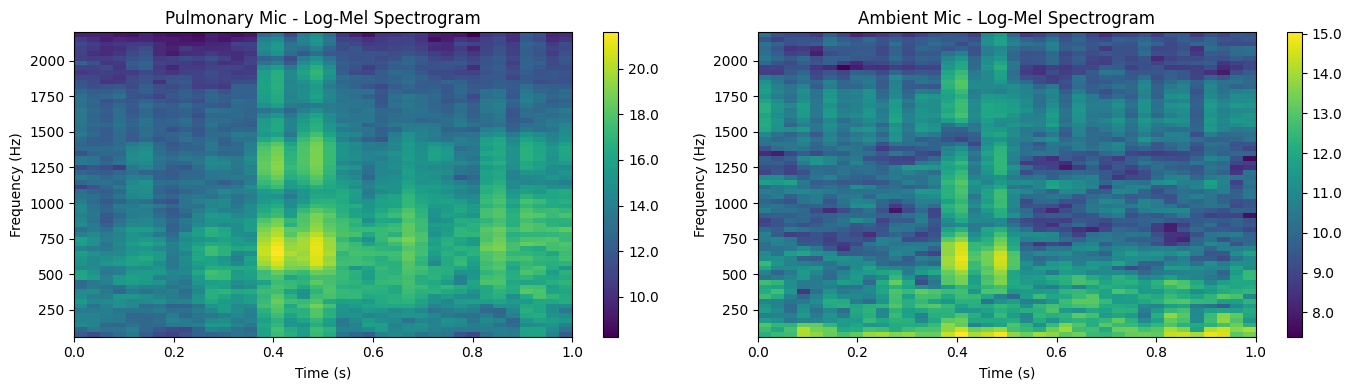

In [4]:
# ---- Mel-spectrogram transform + visual verification ----

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=FS_AUDIO,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    f_min=FMIN,
    f_max=FMAX,
)

def audio_to_log_mel(audio_np):
    """Convert audio windows (N, 2, T) to log-Mel spectrograms (N, 2, n_mels, T_frames)."""
    t = torch.tensor(audio_np, dtype=torch.float32)
    mel = mel_transform(t)
    log_mel = torch.log(mel + 1e-9)
    return log_mel.numpy()

# Quick test on one record
sample_rec = load_record_preprocessed(2, df_meta)
sample_wins = build_centered_windows(sample_rec)
sample_spec = audio_to_log_mel(sample_wins['audio'])

print(f'Audio window shape : {sample_wins["audio"].shape}')
print(f'Spectrogram shape  : {sample_spec.shape}')
print(f'  -> (N_windows, 2_channels, {N_MELS}_mel_bins, T_frames)')

# Plot sample spectrograms
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ch, name in enumerate(['Pulmonary', 'Ambient']):
    im = axes[ch].imshow(
        sample_spec[0, ch], aspect='auto', origin='lower',
        extent=[0, WINDOW_SEC, FMIN, FMAX],
    )
    axes[ch].set_title(f'{name} Mic - Log-Mel Spectrogram')
    axes[ch].set_xlabel('Time (s)')
    axes[ch].set_ylabel('Frequency (Hz)')
    plt.colorbar(im, ax=axes[ch], format='%.1f')
plt.tight_layout()
plt.show()

Saved: ..\report\figures\mel_spectrogram_example.png


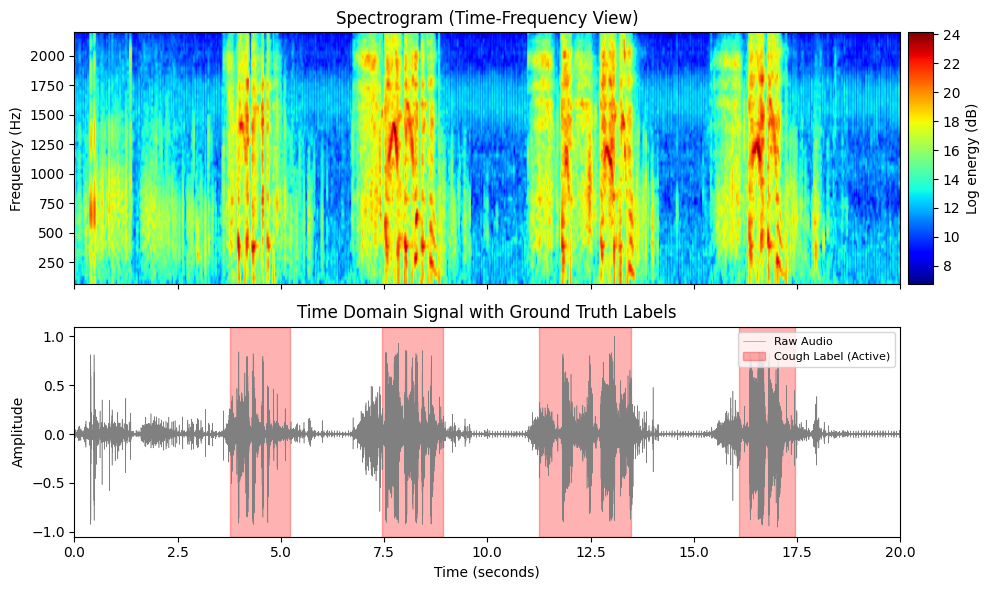

In [8]:
# ---- Publication figure: Spectrogram + Ground Truth (for report) ----
from mpl_toolkits.axes_grid1 import make_axes_locatable

pulm_full = sample_rec['pulm_bp']
cough_full = sample_rec['cough_label']
duration = sample_rec['duration_sec']

t_audio = torch.tensor(pulm_full.copy(), dtype=torch.float32).unsqueeze(0)
mel_full = mel_transform(t_audio)
log_mel_full = torch.log(mel_full + 1e-9).squeeze(0).numpy()

time_axis = np.linspace(0, duration, len(pulm_full))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                         gridspec_kw={'height_ratios': [1.2, 1]})
plt.subplots_adjust(hspace=0.35)

im = axes[0].imshow(
    log_mel_full, aspect='auto', origin='lower',
    extent=[0, duration, FMIN, FMAX],
    cmap='jet',
)
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('Spectrogram (Time-Frequency View)')

divider0 = make_axes_locatable(axes[0])
cax0 = divider0.append_axes('right', size='3%', pad=0.08)
cb = fig.colorbar(im, cax=cax0, format='%.0f')
cb.set_label('Log energy (dB)')

divider1 = make_axes_locatable(axes[1])
cax1 = divider1.append_axes('right', size='3%', pad=0.08)
cax1.axis('off')

pulm_norm = pulm_full / np.max(np.abs(pulm_full))
axes[1].plot(time_axis, pulm_norm, color='gray', linewidth=0.4, label='Raw Audio')
cough_regions = np.where(cough_full > 0)[0]
if len(cough_regions) > 0:
    starts = [cough_regions[0]]
    ends = []
    for i in range(1, len(cough_regions)):
        if cough_regions[i] != cough_regions[i - 1] + 1:
            ends.append(cough_regions[i - 1])
            starts.append(cough_regions[i])
    ends.append(cough_regions[-1])
    for s, e in zip(starts, ends):
        t_s = s / FS_AUDIO
        t_e = e / FS_AUDIO
        axes[1].axvspan(t_s, t_e, alpha=0.3, color='red', label='Cough Label (Active)')

axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Time Domain Signal with Ground Truth Labels')
handles, labels_legend = axes[1].get_legend_handles_labels()
by_label = dict(zip(labels_legend, handles))
axes[1].legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=8)

plt.tight_layout()
save_path = os.path.join('..', 'report', 'figures', 'mel_spectrogram_example.png')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

In [5]:
# ---- Record split + dataset builder ----

def split_records(metadata_df, test_size=0.15, val_size=0.15, random_state=42):
    ids = metadata_df['record_id'].unique()
    train_val, test = train_test_split(ids, test_size=test_size, random_state=random_state)
    train, val = train_test_split(train_val, test_size=val_size/(1-test_size), random_state=random_state)
    return train, val, test

def build_dataset(record_ids, metadata_df):
    """Build spectrogram + motion dataset from a list of record IDs."""
    all_spec, all_motion, all_labels = [], [], []
    for rid in record_ids:
        rec = load_record_preprocessed(rid, metadata_df)
        wins = build_centered_windows(rec)
        if len(wins['labels']) == 0:
            continue
        specs = audio_to_log_mel(wins['audio'])
        all_spec.append(specs)
        all_motion.append(wins['motion'])
        all_labels.append(wins['labels'])
    return np.vstack(all_spec), np.vstack(all_motion), np.concatenate(all_labels)

train_recs, val_recs, test_recs = split_records(df_meta)
print(f'Record split -> Train: {len(train_recs)} | Val: {len(val_recs)} | Test: {len(test_recs)}\n')

X_s_train, X_m_train, y_train = build_dataset(train_recs, df_meta)
X_s_val,   X_m_val,   y_val   = build_dataset(val_recs,   df_meta)
X_s_test,  X_m_test,  y_test  = build_dataset(test_recs,  df_meta)

for name, xs, xm, y in [('Train', X_s_train, X_m_train, y_train),
                         ('Val',   X_s_val,   X_m_val,   y_val),
                         ('Test',  X_s_test,  X_m_test,  y_test)]:
    print(f'{name}: Spec {xs.shape} | Motion {xm.shape} | Positive: {np.sum(y)} ({np.mean(y)*100:.1f}%)')

Record split -> Train: 59 | Val: 13 | Test: 13

Train: Spec (4543, 2, 64, 38) | Motion (4543, 2, 100) | Positive: 788 (17.3%)
Val: Spec (1001, 2, 64, 38) | Motion (1001, 2, 100) | Positive: 226 (22.6%)
Test: Spec (1001, 2, 64, 38) | Motion (1001, 2, 100) | Positive: 192 (19.2%)


In [6]:
# ---- PyTorch Dataset + DataLoaders ----

class SpectrogramDataset(Dataset):
    def __init__(self, X_spec, X_motion, labels, label_dtype=torch.float32):
        self.spec   = torch.tensor(X_spec,   dtype=torch.float32)
        self.motion = torch.tensor(X_motion, dtype=torch.float32)
        self.labels = torch.tensor(labels,   dtype=label_dtype)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {'spec': self.spec[idx], 'motion': self.motion[idx], 'label': self.labels[idx]}

train_loader = DataLoader(SpectrogramDataset(X_s_train, X_m_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SpectrogramDataset(X_s_val,   X_m_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SpectrogramDataset(X_s_test,  X_m_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

print(f'DataLoaders created. Batch size: {BATCH_SIZE}')


DataLoaders created. Batch size: 64


In [7]:
# ---- Model: 2D CNN (spectrogram) + 1D CNN (motion) + Late Fusion ----

class Spec2DCoughCNN(nn.Module):
    """Spectrogram audio branch (2D CNN) + motion branch (1D CNN), fused for classification."""
    def __init__(self, num_classes=1):
        super().__init__()
        self.audio_branch = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.motion_branch = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=5, padding=2), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(96, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, spec, motion):
        xa = self.audio_branch(spec).flatten(1)
        xm = self.motion_branch(motion).flatten(1)
        out = self.classifier(torch.cat([xa, xm], dim=1))
        return out.squeeze(-1) if out.shape[-1] == 1 else out

model = Spec2DCoughCNN(num_classes=1).to(DEVICE)

# Sanity check
with torch.no_grad():
    dummy_spec   = torch.randn(2, 2, N_MELS, sample_spec.shape[-1]).to(DEVICE)
    dummy_motion = torch.randn(2, 2, int(WINDOW_SEC * FS_MOTION)).to(DEVICE)
    dummy_out = model(dummy_spec, dummy_motion)
    print(f'Sanity check passed. Output shape: {dummy_out.shape}')

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')


Sanity check passed. Output shape: torch.Size([2])
Total parameters: 31,777


pos_weight: 4.77  (neg/pos = 3755/788)

Starting Phase 1 Training for 25 epochs...

Epoch 01/25 | LR: 0.00100 | Train Loss: 0.6159 | Val Loss: 1.2543 | Val Acc: 84.7%
Epoch 02/25 | LR: 0.00100 | Train Loss: 0.3449 | Val Loss: 0.7824 | Val Acc: 73.4%
Epoch 03/25 | LR: 0.00100 | Train Loss: 0.3123 | Val Loss: 1.1607 | Val Acc: 71.5%
Epoch 04/25 | LR: 0.00100 | Train Loss: 0.2955 | Val Loss: 1.5573 | Val Acc: 66.2%
Epoch 05/25 | LR: 0.00100 | Train Loss: 0.2928 | Val Loss: 3.1897 | Val Acc: 80.2%
Epoch 06/25 | LR: 0.00050 | Train Loss: 0.2704 | Val Loss: 1.5760 | Val Acc: 67.7%
Epoch 07/25 | LR: 0.00050 | Train Loss: 0.2545 | Val Loss: 0.5279 | Val Acc: 83.7%
Epoch 08/25 | LR: 0.00050 | Train Loss: 0.2406 | Val Loss: 0.6139 | Val Acc: 80.9%
Epoch 09/25 | LR: 0.00050 | Train Loss: 0.2435 | Val Loss: 0.5824 | Val Acc: 74.8%
Epoch 10/25 | LR: 0.00050 | Train Loss: 0.2288 | Val Loss: 0.9755 | Val Acc: 91.3%
Epoch 11/25 | LR: 0.00050 | Train Loss: 0.2330 | Val Loss: 0.4375 | Val Acc: 85.7%
Epo

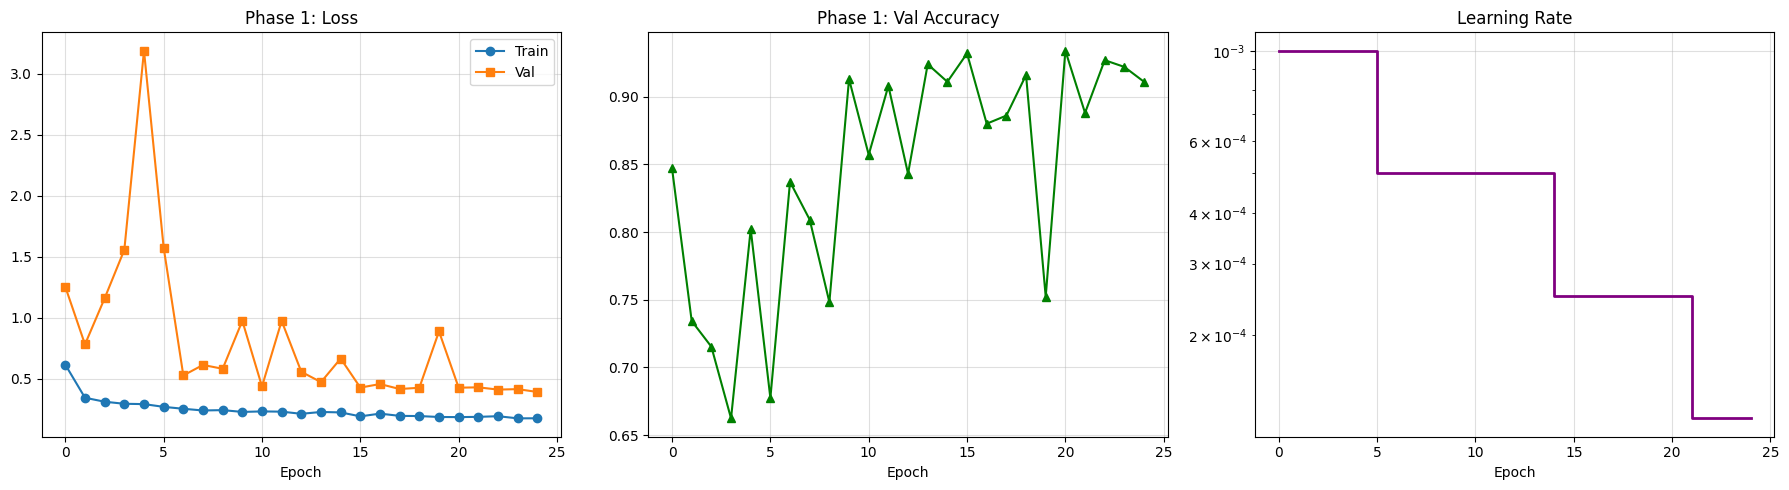

In [8]:
# ---- Phase 1 Training: Cough Detection ----

num_pos = np.sum(y_train)
num_neg = len(y_train) - num_pos
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32, device=DEVICE)
print(f'pos_weight: {pos_weight.item():.2f}  (neg/pos = {num_neg}/{num_pos})')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

train_losses, val_losses, val_accs, lr_hist = [], [], [], []

print(f'\nStarting Phase 1 Training for {NUM_EPOCHS} epochs...\n')
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        spec   = batch['spec'].to(DEVICE)
        motion = batch['motion'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        logits = model(spec, motion)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * spec.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            spec   = batch['spec'].to(DEVICE)
            motion = batch['motion'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            logits = model(spec, motion)
            loss = criterion(logits, labels)
            running_val_loss += loss.item() * spec.size(0)

            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc  = correct / total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    lr_hist.append(current_lr)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | LR: {current_lr:.5f} | '
          f'Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.1f}%')

# Learning curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(train_losses, label='Train', marker='o')
axes[0].plot(val_losses, label='Val', marker='s')
axes[0].set_title('Phase 1: Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(val_accs, label='Val Acc', color='green', marker='^')
axes[1].set_title('Phase 1: Val Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.4)

axes[2].step(range(NUM_EPOCHS), lr_hist, where='post', color='purple', linewidth=2)
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch'); axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


--- Phase 1 Test Results (Cough Detection) ---

              precision    recall  f1-score   support

   Non-Cough       0.99      0.92      0.95       809
       Cough       0.74      0.95      0.83       192

    accuracy                           0.93      1001
   macro avg       0.86      0.94      0.89      1001
weighted avg       0.94      0.93      0.93      1001



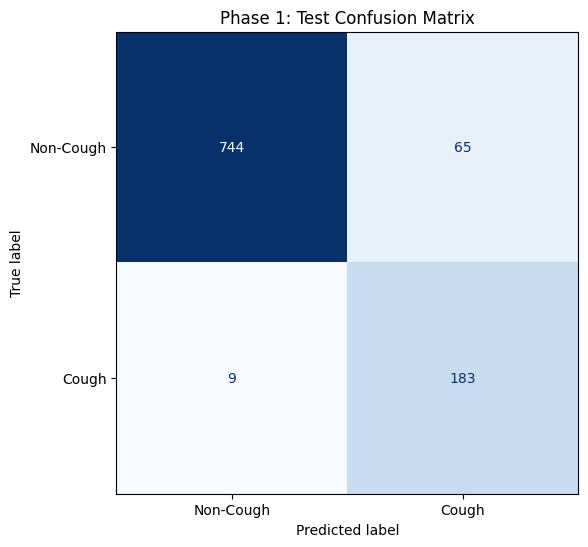

In [9]:
# ---- Phase 1 Evaluation ----

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        spec   = batch['spec'].to(DEVICE)
        motion = batch['motion'].to(DEVICE)
        labels = batch['label']

        logits = model(spec, motion)
        preds = (torch.sigmoid(logits) >= 0.5).int().cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('--- Phase 1 Test Results (Cough Detection) ---\n')
print(classification_report(all_labels, all_preds, target_names=['Non-Cough', 'Cough']))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Cough', 'Cough'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Phase 1: Test Confusion Matrix')
plt.show()


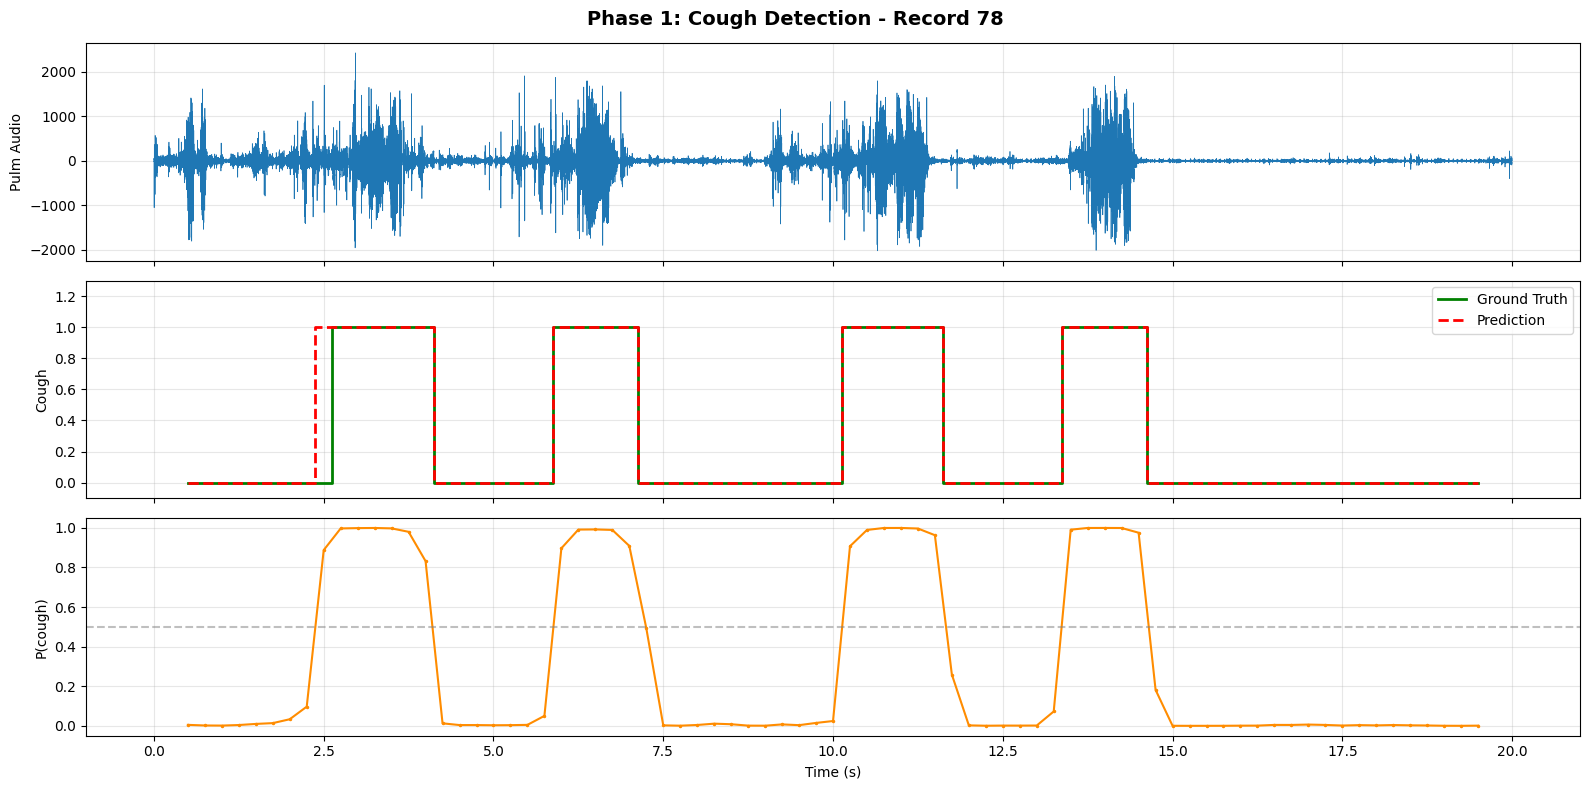

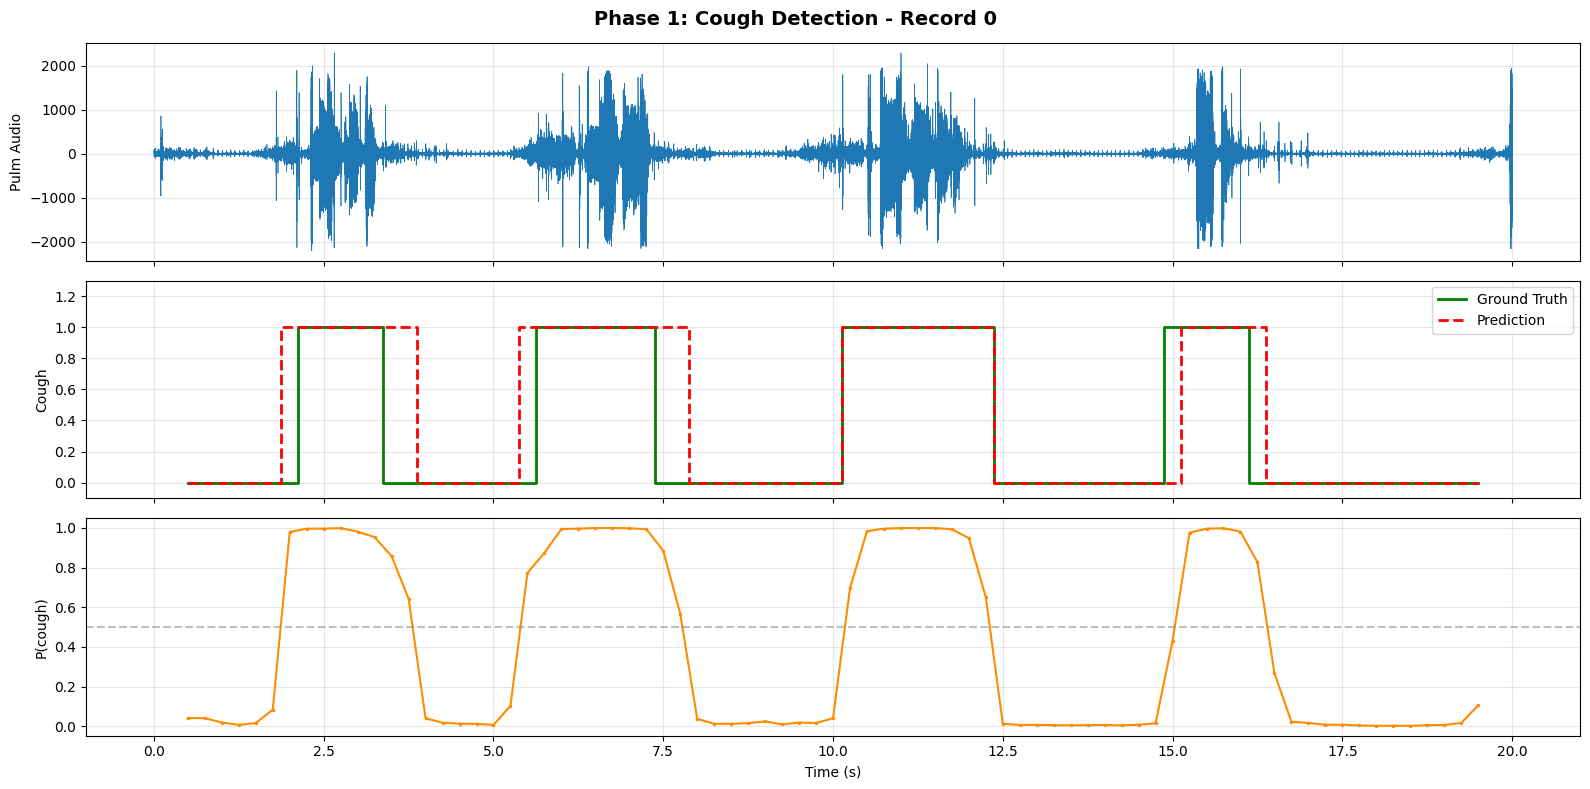

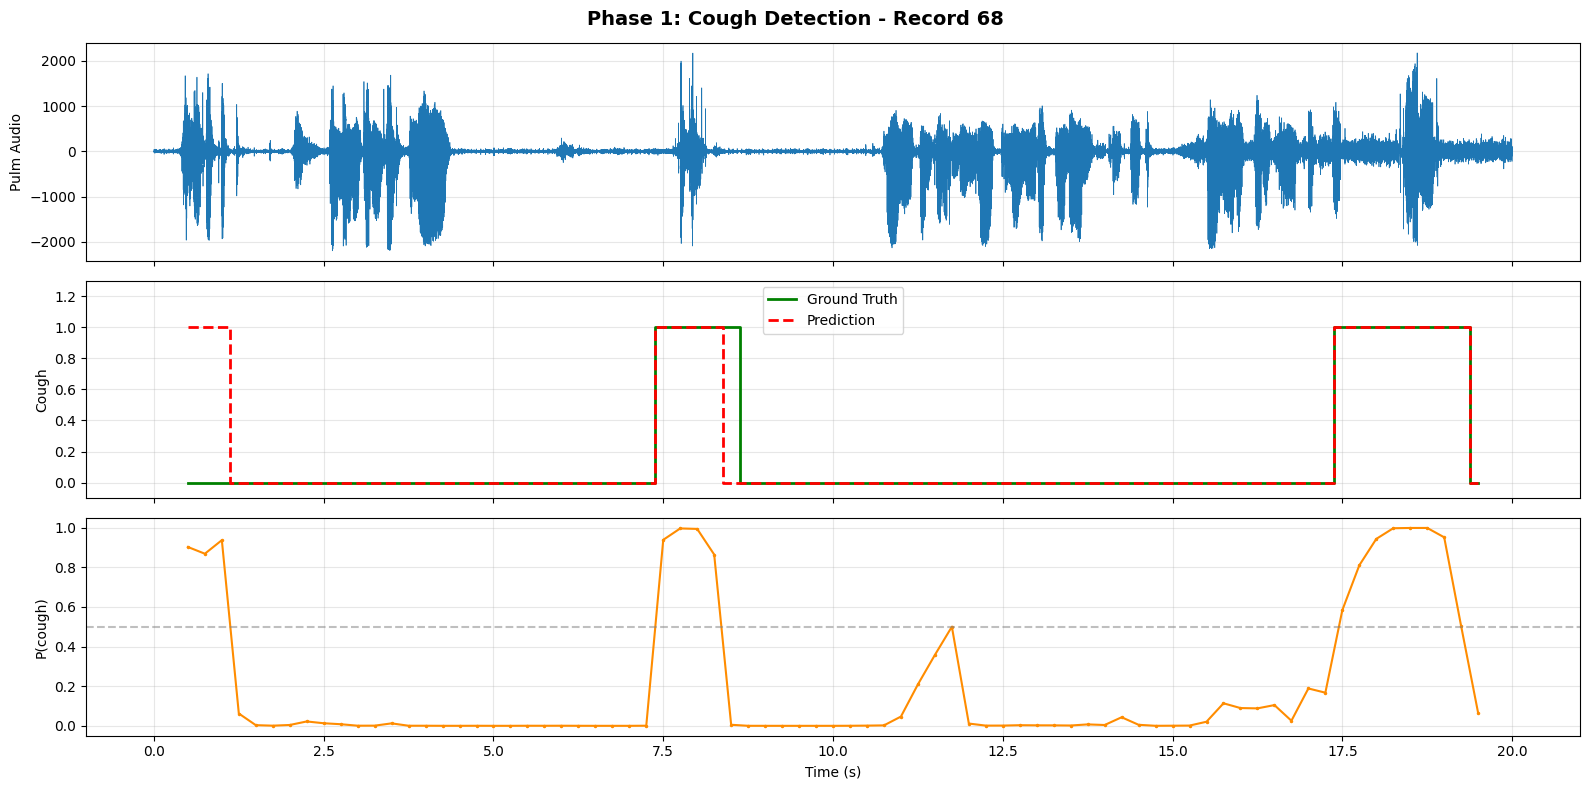

In [10]:
# ---- Phase 1: Time-aligned visualization on sample test records ----

def visualize_cough_predictions(record_id, metadata_df=df_meta, mdl=model):
    rec  = load_record_preprocessed(record_id, metadata_df)
    wins = build_centered_windows(rec)
    specs = audio_to_log_mel(wins['audio'])

    mdl.eval()
    with torch.no_grad():
        spec_t   = torch.tensor(specs, dtype=torch.float32, device=DEVICE)
        motion_t = torch.tensor(wins['motion'], dtype=torch.float32, device=DEVICE)
        logits = mdl(spec_t, motion_t)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= 0.5).astype(int)

    gt = wins['labels']
    spans = wins['spans']
    t_centers = [(s+e)/2 for s, e in spans]

    duration = rec['duration_sec']
    t_audio = np.linspace(0, duration, len(rec['pulm_bp']), endpoint=False)

    fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f'Phase 1: Cough Detection - Record {record_id}', fontsize=14, fontweight='bold')

    axes[0].plot(t_audio, rec['pulm_bp'], linewidth=0.5)
    axes[0].set_ylabel('Pulm Audio'); axes[0].grid(True, alpha=0.3)

    axes[1].step(t_centers, gt, where='mid', color='green', label='Ground Truth', linewidth=2)
    axes[1].step(t_centers, preds, where='mid', color='red', label='Prediction', linewidth=2, linestyle='--')
    axes[1].set_ylabel('Cough'); axes[1].legend(); axes[1].set_ylim(-0.1, 1.3); axes[1].grid(True, alpha=0.3)

    axes[2].plot(t_centers, probs, color='darkorange', marker='.', markersize=3)
    axes[2].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_ylabel('P(cough)'); axes[2].set_xlabel('Time (s)'); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

for rid in test_recs[:3]:
    visualize_cough_predictions(rid)

---
## Phase 2: Activity Classification

Each window inherits its record-level activity label (sitting, walking, etc.).
The **running** class is excluded (too few samples for stable train/val/test splits).
Same spectrogram + 2D CNN architecture, but the output head becomes multi-class.

In [11]:
# ---- Phase 2: Setup (Stratified record split) ----

activity_by_record = df_meta.set_index('record_id')['activity'].to_dict()

# Exclude 'running': too few records; often unstable in test after splitting
EXCLUDE_ACTIVITIES_P2 = {'running'}

eligible = df_meta[~df_meta['activity'].isin(EXCLUDE_ACTIVITIES_P2)][['record_id', 'activity']].drop_duplicates()
eligible_ids = eligible['record_id'].to_numpy()
eligible_labels = eligible['activity'].to_numpy()

sss_test = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(sss_test.split(eligible_ids, eligible_labels))

ids_train_val = eligible_ids[train_val_idx]
labels_train_val = eligible_labels[train_val_idx]
ids_test = eligible_ids[test_idx]

val_ratio_from_trainval = 0.15 / (1 - 0.15)
sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio_from_trainval, random_state=42)
train_idx, val_idx = next(sss_val.split(ids_train_val, labels_train_val))

train_recs_p2 = ids_train_val[train_idx].tolist()
val_recs_p2 = ids_train_val[val_idx].tolist()
test_recs_p2 = ids_test.tolist()

activity_classes = sorted(set(activity_by_record[r] for r in (train_recs_p2 + val_recs_p2 + test_recs_p2)))
activity_to_idx = {a: i for i, a in enumerate(activity_classes)}
num_classes_p2 = len(activity_classes)

print(f'Activity classes: {activity_classes}')
print(f'Records -> Train: {len(train_recs_p2)} | Val: {len(val_recs_p2)} | Test: {len(test_recs_p2)}')

def print_split_counts(name, record_ids):
    labels = [activity_by_record[r] for r in record_ids]
    counts = pd.Series(labels).value_counts().reindex(activity_classes, fill_value=0)
    print(f'{name} class counts: {counts.to_dict()}')

print_split_counts('Train', train_recs_p2)
print_split_counts('Val', val_recs_p2)
print_split_counts('Test', test_recs_p2)

def build_activity_dataset(record_ids, metadata_df):
    all_spec, all_motion, all_labels = [], [], []
    for rid in record_ids:
        act = activity_by_record.get(rid)
        if act is None or act not in activity_to_idx:
            continue
        rec = load_record_preprocessed(rid, metadata_df)
        wins = build_centered_windows(rec)
        n = len(wins['labels'])
        if n == 0:
            continue
        specs = audio_to_log_mel(wins['audio'])
        all_spec.append(specs)
        all_motion.append(wins['motion'])
        all_labels.append(np.full(n, activity_to_idx[act], dtype=np.int64))
    return np.vstack(all_spec), np.vstack(all_motion), np.concatenate(all_labels)

X_s_train_p2, X_m_train_p2, y_train_p2 = build_activity_dataset(train_recs_p2, df_meta)
X_s_val_p2,   X_m_val_p2,   y_val_p2   = build_activity_dataset(val_recs_p2,   df_meta)
X_s_test_p2,  X_m_test_p2,  y_test_p2  = build_activity_dataset(test_recs_p2,  df_meta)

print(f'\nTrain: {X_s_train_p2.shape} | Val: {X_s_val_p2.shape} | Test: {X_s_test_p2.shape}')
print(f'Train window class counts: {np.bincount(y_train_p2, minlength=num_classes_p2)}')
print(f'Val window class counts: {np.bincount(y_val_p2, minlength=num_classes_p2)}')
print(f'Test window class counts: {np.bincount(y_test_p2, minlength=num_classes_p2)}')

Activity classes: ['sitting', 'standing', 'walking']
Records -> Train: 56 | Val: 12 | Test: 12
Train class counts: {'sitting': 29, 'standing': 11, 'walking': 16}
Val class counts: {'sitting': 7, 'standing': 2, 'walking': 3}
Test class counts: {'sitting': 7, 'standing': 2, 'walking': 3}

Train: (4312, 2, 64, 38) | Val: (924, 2, 64, 38) | Test: (924, 2, 64, 38)
Train window class counts: [2233  847 1232]
Val window class counts: [539 154 231]
Test window class counts: [539 154 231]


Phase 2 A/B runs: 4 configs, 12 epochs each

=== Run-A (baseline) ===
Run-A Epoch 01/12 | LR 0.001000 | Train Loss 0.6594 Acc 72.0% | Val Loss 0.9584 Acc 69.5%
Run-A Epoch 02/12 | LR 0.001000 | Train Loss 0.3944 Acc 85.3% | Val Loss 0.5850 Acc 75.2%
Run-A Epoch 03/12 | LR 0.001000 | Train Loss 0.3134 Acc 89.2% | Val Loss 0.8576 Acc 70.6%
Run-A Epoch 04/12 | LR 0.001000 | Train Loss 0.2647 Acc 90.8% | Val Loss 0.5646 Acc 78.0%
Run-A Epoch 05/12 | LR 0.001000 | Train Loss 0.2378 Acc 91.5% | Val Loss 0.9376 Acc 60.6%
Run-A Epoch 06/12 | LR 0.001000 | Train Loss 0.1972 Acc 93.2% | Val Loss 0.9236 Acc 62.9%
Run-A Epoch 07/12 | LR 0.001000 | Train Loss 0.1871 Acc 93.3% | Val Loss 0.5724 Acc 78.1%
Run-A Epoch 08/12 | LR 0.000500 | Train Loss 0.1837 Acc 93.6% | Val Loss 1.0363 Acc 70.2%
Run-A Epoch 09/12 | LR 0.000500 | Train Loss 0.1551 Acc 94.3% | Val Loss 0.5879 Acc 76.1%
Run-A Epoch 10/12 | LR 0.000500 | Train Loss 0.1491 Acc 94.5% | Val Loss 0.5743 Acc 80.1%
Run-A Epoch 11/12 | LR 0.00050

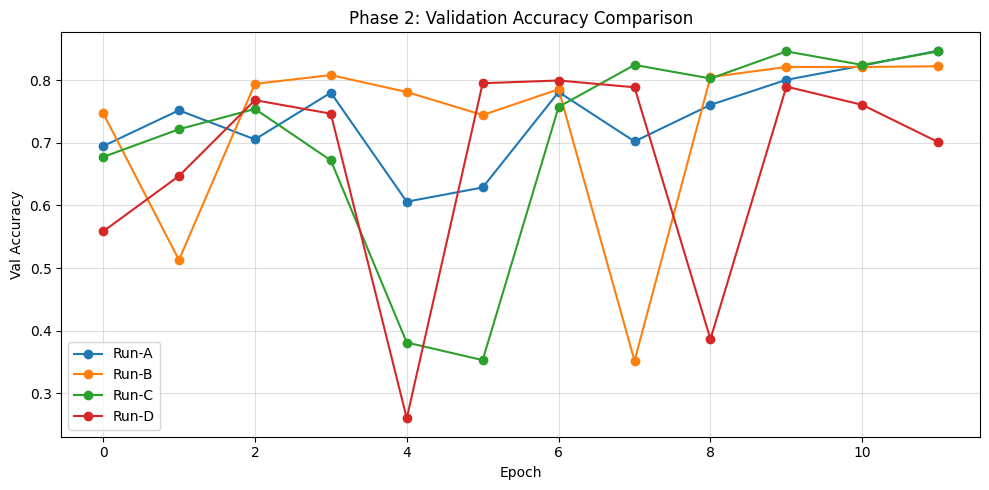

In [12]:
# ---- Phase 2: Model + A/B Experiment Training ----

BATCH_SIZE_P2 = 32
NUM_EPOCHS_P2 = 12

train_ds_p2 = SpectrogramDataset(X_s_train_p2, X_m_train_p2, y_train_p2, label_dtype=torch.long)
val_ds_p2 = SpectrogramDataset(X_s_val_p2, X_m_val_p2, y_val_p2, label_dtype=torch.long)
test_ds_p2 = SpectrogramDataset(X_s_test_p2, X_m_test_p2, y_test_p2, label_dtype=torch.long)

val_loader_p2 = DataLoader(val_ds_p2, batch_size=BATCH_SIZE_P2, shuffle=False)
test_loader_p2 = DataLoader(test_ds_p2, batch_size=BATCH_SIZE_P2, shuffle=False)

class_counts = np.bincount(y_train_p2, minlength=num_classes_p2).astype(np.float32)
inv_freq = 1.0 / (class_counts + 1e-6)
class_weights = (class_counts.sum() / (class_counts + 1e-6)).astype(np.float32)

sample_weights = inv_freq[y_train_p2]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)

EXPERIMENTS_P2 = [
    {'name': 'Run-A', 'desc': 'baseline', 'use_class_weights': False, 'use_sampler': False},
    {'name': 'Run-B', 'desc': 'stratified + class weights', 'use_class_weights': True, 'use_sampler': False},
    {'name': 'Run-C', 'desc': 'stratified + weighted sampler', 'use_class_weights': False, 'use_sampler': True},
    {'name': 'Run-D', 'desc': 'stratified + class weights + sampler', 'use_class_weights': True, 'use_sampler': True},
]

run_artifacts = {}
print(f'Phase 2 A/B runs: {len(EXPERIMENTS_P2)} configs, {NUM_EPOCHS_P2} epochs each\n')

for cfg in EXPERIMENTS_P2:
    print(f"=== {cfg['name']} ({cfg['desc']}) ===")

    train_loader_p2 = DataLoader(
        train_ds_p2,
        batch_size=BATCH_SIZE_P2,
        shuffle=not cfg['use_sampler'],
        sampler=sampler if cfg['use_sampler'] else None,
    )

    model_p2 = Spec2DCoughCNN(num_classes=num_classes_p2).to(DEVICE)
    criterion_p2 = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
    ) if cfg['use_class_weights'] else nn.CrossEntropyLoss()

    optimizer_p2 = optim.AdamW(model_p2.parameters(), lr=LR, weight_decay=1e-4)
    scheduler_p2 = ReduceLROnPlateau(optimizer_p2, mode='min', factor=0.5, patience=3)

    train_losses, val_losses, val_accs = [], [], []
    best_state, best_val_loss = None, np.inf

    for epoch in range(NUM_EPOCHS_P2):
        model_p2.train()
        running_loss, n_train, correct = 0.0, 0, 0
        for batch in train_loader_p2:
            spec = batch['spec'].to(DEVICE)
            motion = batch['motion'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            optimizer_p2.zero_grad()
            logits = model_p2(spec, motion)
            loss = criterion_p2(logits, labels)
            loss.backward()
            optimizer_p2.step()

            bs = spec.size(0)
            running_loss += loss.item() * bs
            n_train += bs
            correct += (logits.argmax(1) == labels).sum().item()

        epoch_train_loss = running_loss / max(n_train, 1)
        epoch_train_acc = correct / max(n_train, 1)
        train_losses.append(epoch_train_loss)

        model_p2.eval()
        running_val_loss, n_val, correct_val = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader_p2:
                spec = batch['spec'].to(DEVICE)
                motion = batch['motion'].to(DEVICE)
                labels = batch['label'].to(DEVICE)
                logits = model_p2(spec, motion)
                loss = criterion_p2(logits, labels)

                bs = spec.size(0)
                running_val_loss += loss.item() * bs
                n_val += bs
                correct_val += (logits.argmax(1) == labels).sum().item()

        epoch_val_loss = running_val_loss / max(n_val, 1)
        epoch_val_acc = correct_val / max(n_val, 1)
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model_p2.state_dict().items()}

        scheduler_p2.step(epoch_val_loss)
        lr_now = optimizer_p2.param_groups[0]['lr']

        print(
            f"{cfg['name']} Epoch {epoch+1:02d}/{NUM_EPOCHS_P2} | LR {lr_now:.6f} | "
            f"Train Loss {epoch_train_loss:.4f} Acc {epoch_train_acc*100:.1f}% | "
            f"Val Loss {epoch_val_loss:.4f} Acc {epoch_val_acc*100:.1f}%"
        )

    run_artifacts[cfg['name']] = {
        'config': cfg,
        'best_val_loss': float(best_val_loss),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'state_dict': best_state,
    }

    print()

# Plot one compact comparison for validation accuracy curves
fig, ax = plt.subplots(figsize=(10, 5))
for run_name, art in run_artifacts.items():
    ax.plot(art['val_accs'], marker='o', label=run_name)
ax.set_title('Phase 2: Validation Accuracy Comparison')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy')
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


--- Phase 2 A/B Test Summary ---

  run  standing_recall  macro_f1  walking_recall  overall_acc  best_val_loss  walking_drop_vs_baseline
Run-B           0.8571    0.9109          0.8052       0.9232         0.4383                    0.0346
Run-D           0.7987    0.8673          0.8528       0.8766         0.5843                    0.0823
Run-C           0.5714    0.8276          0.7792       0.8680         0.4089                    0.0087
Run-A           0.4286    0.7736          0.7706       0.8398         0.4595                    0.0000

Runs passing walking guardrail (drop >= -0.05):
  run  standing_recall  macro_f1  walking_recall  overall_acc  best_val_loss  walking_drop_vs_baseline
Run-B           0.8571    0.9109          0.8052       0.9232         0.4383                    0.0346
Run-D           0.7987    0.8673          0.8528       0.8766         0.5843                    0.0823
Run-C           0.5714    0.8276          0.7792       0.8680         0.4089                 

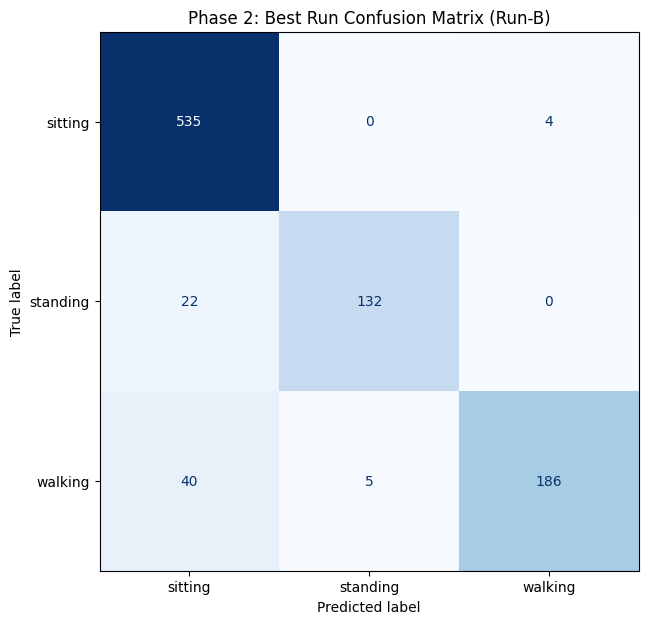


Guardrail: walking recall drop should stay >= -0.05 vs Run-A baseline.
Run-B: walking_drop_vs_baseline=0.0346
Run-D: walking_drop_vs_baseline=0.0823
Run-C: walking_drop_vs_baseline=0.0087
Run-A: walking_drop_vs_baseline=0.0000


In [13]:
# ---- Phase 2 Evaluation (Run-A/B/C/D comparison) ----

def evaluate_loader(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for batch in loader:
            spec = batch['spec'].to(DEVICE)
            motion = batch['motion'].to(DEVICE)
            labels = batch['label']
            logits = model(spec, motion)
            preds = logits.argmax(1).cpu().numpy()
            preds_all.extend(preds)
            labels_all.extend(labels.numpy())
    return np.array(labels_all), np.array(preds_all)

results_rows = []
run_predictions = {}
standing_idx = activity_to_idx['standing']
walking_idx = activity_to_idx['walking']

for run_name, art in run_artifacts.items():
    model_eval = Spec2DCoughCNN(num_classes=num_classes_p2).to(DEVICE)
    model_eval.load_state_dict(art['state_dict'])

    y_true, y_pred = evaluate_loader(model_eval, test_loader_p2)
    run_predictions[run_name] = (y_true, y_pred)

    standing_recall = recall_score(y_true, y_pred, labels=[standing_idx], average='macro', zero_division=0)
    walking_recall = recall_score(y_true, y_pred, labels=[walking_idx], average='macro', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    overall_acc = float((y_true == y_pred).mean())

    results_rows.append({
        'run': run_name,
        'standing_recall': standing_recall,
        'macro_f1': macro_f1,
        'walking_recall': walking_recall,
        'overall_acc': overall_acc,
        'best_val_loss': art['best_val_loss'],
    })

results_df = pd.DataFrame(results_rows)
baseline_walk = float(results_df.loc[results_df['run'] == 'Run-A', 'walking_recall'].iloc[0])
results_df['walking_drop_vs_baseline'] = results_df['walking_recall'] - baseline_walk

results_df = results_df.sort_values(
    ['standing_recall', 'macro_f1', 'walking_recall'], ascending=False
).reset_index(drop=True)

print('--- Phase 2 A/B Test Summary ---\n')
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

guardrail_threshold = -0.05
eligible_df = results_df[results_df['walking_drop_vs_baseline'] >= guardrail_threshold].copy()

if len(eligible_df) == 0:
    print('\nNo run passed walking guardrail. Falling back to best standing_recall + macro_f1.')
    best_run = results_df.iloc[0]['run']
else:
    eligible_df = eligible_df.sort_values(
        ['standing_recall', 'macro_f1', 'walking_recall'], ascending=False
    ).reset_index(drop=True)
    print('\nRuns passing walking guardrail (drop >= -0.05):')
    print(eligible_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    best_run = eligible_df.iloc[0]['run']

y_true_best, y_pred_best = run_predictions[best_run]

print(f"\nSelected best run (guardrail + standing recall + macro-F1): {best_run}\n")
print(classification_report(
    y_true_best, y_pred_best,
    labels=list(range(num_classes_p2)),
    target_names=activity_classes,
    zero_division=0,
))

cm_p2 = confusion_matrix(y_true_best, y_pred_best, labels=list(range(num_classes_p2)))
disp_p2 = ConfusionMatrixDisplay(confusion_matrix=cm_p2, display_labels=activity_classes)
fig, ax = plt.subplots(figsize=(7, 7))
disp_p2.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Phase 2: Best Run Confusion Matrix ({best_run})')
plt.show()

# Guardrail quick check
print('\nGuardrail: walking recall drop should stay >= -0.05 vs Run-A baseline.')
for _, row in results_df.iterrows():
    print(f"{row['run']}: walking_drop_vs_baseline={row['walking_drop_vs_baseline']:.4f}")
